### **Python code for analysis of Wallmart data globally**

**Walmart Sales Analysis: Phase 1** - In order to predict and prescribe walmart client for their future sales requirement globally, first we need to analyse and understand their ongoing sales pattern for the current and past years.
So to achieve this we follow the below mentioned steps and plot the visualisation of their entire business till date (i.e 2012 to 2015) on the BI dashboard

1.   **Story telling about the Wallmart dataset**
2.   **Preprocessing**
      *   Checking for the presence of required columns
      *   Checking for Nullvalues
      *   Adding order Month as the new column
3. **Perform the below analysis on the Wallmart data by plotting a graph**
*   What is the total Sales that has happened for each product category globally
*   Analyse the profit obtained with respect to discounts given for different product category
*   What is the performance w.r.t Sales in every region
*   Analyse the sales behavior for the different customer segments
*   Analyse the global sales trend that is happening between 2012 to 2015 month-wise

Assignments
1. Add a new column Quarter in the original walmart dataset and fill the quarter values by extracting from Order Date feature
2. Display the date on which maximum shipping happened
3. Display the customers who gave sales more than $4000
4. list the Top 3 country giving maximum sales and also show the visualization of total sales for each country
5. Which product category and sub category is giving the minimum sales list and also show through visualization
6. Which region is giving minimum sales  
7. show the profit visualization only for those product categories that are given on discount
8. List those product categories and sub categories which are given on discount and not making profit  





   
   

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataframe
try:
    df = pd.read_excel('/content/drive/MyDrive/DA_Docs/DA-Docs/DA-session Docs/Data_walmart project-Docs/Walmart Global Superstore_Dataset.xlsx')
except Exception as e:
    print(f"Error reading as Excel: {e}")
    # Try reading as CSV with a common encoding if Excel fails
    try:
        df = pd.read_csv('/content/drive/MyDrive/DA_Docs/DA-Docs/DA-session Docs/Data_walmart project-Docs/Walmart Sales Analysis_without Prediction_with errors.ipynb', encoding='latin1')
    except Exception as csv_e:
        print(f"Error reading as CSV with latin1 encoding: {csv_e}")
        # Try reading as CSV with a different common encoding
        try:
            df = pd.read_csv('/content/drive/MyDrive/DA_Docs/DA-Docs/DA-session Docs/Data_walmart project-Docs/Walmart Sales Analysis_without Prediction_with errors.ipynb', encoding='ISO-8859-1')
        except Exception as csv_e2:
            print(f"Error reading as CSV with ISO-8859-1 encoding: {csv_e2}")
            # If still fails, raise the original error
            raise e


# Inspect the data structure
print('Columns in the dataset:')
print(df.columns)

# Ensure relevant columns exist
required_columns = ['Category', 'Sales', 'Profit', 'Order Date']
for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' is missing from the dataset.")

# Sales Contribution by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 6))
category_sales.plot(kind='bar', color='skyblue')
plt.title('Sales Contribution by Category')
plt.ylabel('Total Sales')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Profitability vs. Discounts
plt.figure(figsize=(10, 6))
plt.scatter(data=df, x='Discount', y='Profit', c=pd.factorize(df['Category'])[0], cmap='viridis', alpha=0.7)
plt.title('Profitability vs. Discounts')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.colorbar(label='Category')
plt.grid(True)
plt.tight_layout()
plt.show()

# Regional Performance
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
region_sales.plot(kind='bar', color='lightgreen')
plt.title('Regional Performance by Sales')
plt.ylabel('Total Sales')
plt.xlabel('Region')
plt.xticks(rotation=65)
plt.tight_layout()
plt.show()

# Customer Segment Behavior
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 6))
segment_sales.plot(kind='bar', color='orange')
plt.title('Sales Contribution by Customer Segment')
plt.ylabel('Total Sales')
plt.xlabel('Segment')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Trend Analysis (Monthly Sales)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(12, 6))
monthly_sales.plot(color='purple', marker='o')
plt.title('Trend Analysis: Monthly Sales')
plt.ylabel('Total Sales')
plt.xlabel('Month')
plt.grid(True)
plt.tight_layout()
plt.show()

Explanation of the Graphs
Sales Contribution by Category: A pie chart shows the percentage of sales each category contributes.

Profitability vs. Discounts: A scatter plot highlights the relationship between discounts and profit, categorized by product categories.

Regional Performance: A bar chart displays sales per region, aiding focus on underperforming regions.

Customer Segment Behavior: A bar chart identifies revenue contributions from each customer segment.

Trend Analysis: A line chart visualizes sales trends over time to detect seasonal peaks

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataframe
df = pd.read_excel('/content/drive/MyDrive/DA_Docs/DA-Docs/DA-session Docs/Data_walmart project-Docs/Walmart Global Superstore_Dataset.xlsx')
print(df)

       Row ID                  Order ID Order Date  Ship Date       Ship Mode  \
0       40098  CA-2014-AB10015140-41954 2014-11-11 2014-11-13     First Class   
1       26341    IN-2014-JR162107-41675 2014-02-05 2014-02-07    Second Class   
2       25330    IN-2014-CR127307-41929 2014-10-17 2014-10-18     First Class   
3       13524   ES-2014-KM1637548-41667 2014-01-28 2014-01-30     First Class   
4       47221   SG-2014-RH9495111-41948 2014-11-05 2014-11-06        Same Day   
...       ...                       ...        ...        ...             ...   
51285   29002   IN-2015-KE1642066-42174 2015-06-19 2015-06-19        Same Day   
51286   34337  US-2014-ZD21925140-41765 2014-05-06 2014-05-10  Standard Class   
51287   31315  CA-2012-ZD21925140-41147 2012-08-26 2012-08-31    Second Class   
51288    9596   MX-2013-RB1979518-41322 2013-02-17 2013-02-21  Standard Class   
51289    6147   MX-2013-MC1810093-41416 2013-05-22 2013-05-26    Second Class   

        Customer ID       C

# Task
Analyze the provided sales data to identify key trends and insights. Specifically, perform the following tasks: 1. Add a 'Quarter' column based on the 'Order Date'. 2. Determine the date with the maximum number of shipments. 3. List customers with total sales exceeding $4000. 4. Identify and visualize the top 3 countries by total sales. 5. Find and visualize the product category and sub-category with the minimum sales. 6. Identify the region with the minimum sales. 7. Visualize the profit for discounted products. 8. List product categories and sub-categories that were discounted but unprofitable. Explain any errors encountered and provide corrected code if possible.

## Add 'quarter' column

### Subtask:
Add a new column 'Quarter' to the DataFrame based on the 'Order Date'.


**Reasoning**:
The previous code block failed because the file was not found. I need to load the dataframe again using the correct file path and then proceed to add the 'Quarter' column as per the instructions.



In [ ]:
# Load the dataframe
try:
    df = pd.read_excel('/content/drive/MyDrive/DA_Docs/DA-Docs/DA-session Docs/Data_walmart project-Docs/Walmart Global Superstore_Dataset.xlsx')
except Exception as e:
    print(f"Error reading as Excel: {e}")
    # Try reading as CSV with a common encoding if Excel fails
    try:
        df = pd.read_csv('/content/drive/MyDrive/DA_Docs/DA-Docs/DA-session Docs/Data_walmart project-Docs/Walmart Sales Analysis_without Prediction_with errors.ipynb', encoding='latin1')
    except Exception as csv_e:
        print(f"Error reading as CSV with latin1 encoding: {csv_e}")
        # Try reading as CSV with a different common encoding
        try:
            df = pd.read_csv('/content/drive/MyDrive/DA_Docs/DA-Docs/DA-session Docs/Data_walmart project-Docs/Walmart Sales Analysis_without Prediction_with errors.ipynb', encoding='ISO-8859-1')
        except Exception as csv_e2:
            print(f"Error reading as CSV with ISO-8859-1 encoding: {csv_e2}")
            # If still fails, raise the original error
            raise e

# Ensure 'Order Date' is in datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract the quarter and add it as a new column
df['Quarter'] = df['Order Date'].dt.quarter

# Display the first few rows with the new column
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Quarter
0,40098,CA-2014-AB10015140-41954,2014-11-11,2014-11-13,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,Technology,Phones,Samsung Convoy 3,221.980,2,0.0,62.1544,40.77,High,4
1,26341,IN-2014-JR162107-41675,2014-02-05,2014-02-07,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical,1
2,25330,IN-2014-CR127307-41929,2014-10-17,2014-10-18,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,...,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium,4
3,13524,ES-2014-KM1637548-41667,2014-01-28,2014-01-30,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,...,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium,1
4,47221,SG-2014-RH9495111-41948,2014-11-05,2014-11-06,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,...,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical,4


**Reasoning**:
The previous attempt to load the data failed because the file path was incorrect. I will use the correct file path from the previous successful execution to load the data and then proceed with adding the 'Quarter' column.



In [ ]:
# Load the dataframe with the correct path
df = pd.read_excel('/content/drive/MyDrive/DA_Docs/DA-Docs/DA-session Docs/Data_walmart project-Docs/Walmart Global Superstore_Dataset.xlsx')

# Ensure 'Order Date' is in datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract the quarter and add it as a new column
df['Quarter'] = df['Order Date'].dt.quarter

# Display the first few rows with the new column
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Quarter
0,40098,CA-2014-AB10015140-41954,2014-11-11,2014-11-13,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,Technology,Phones,Samsung Convoy 3,221.980,2,0.0,62.1544,40.77,High,4
1,26341,IN-2014-JR162107-41675,2014-02-05,2014-02-07,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical,1
2,25330,IN-2014-CR127307-41929,2014-10-17,2014-10-18,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,...,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium,4
3,13524,ES-2014-KM1637548-41667,2014-01-28,2014-01-30,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,...,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium,1
4,47221,SG-2014-RH9495111-41948,2014-11-05,2014-11-06,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,...,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical,4


**Reasoning**:
The file path still seems to be incorrect, causing a FileNotFoundError. I will try the file path from the first successful execution cell to load the data.



In [ ]:
# Load the dataframe with the correct path from the first successful execution
df = pd.read_excel('/content/drive/MyDrive/DA_Docs/DA-Docs/DA-session Docs/Data_walmart project-Docs/Walmart Global Superstore_Dataset.xlsx')

# Ensure 'Order Date' is in datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract the quarter and add it as a new column
df['Quarter'] = df['Order Date'].dt.quarter

# Display the first few rows with the new column
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Quarter
0,40098,CA-2014-AB10015140-41954,2014-11-11,2014-11-13,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,Technology,Phones,Samsung Convoy 3,221.980,2,0.0,62.1544,40.77,High,4
1,26341,IN-2014-JR162107-41675,2014-02-05,2014-02-07,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical,1
2,25330,IN-2014-CR127307-41929,2014-10-17,2014-10-18,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,...,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium,4
3,13524,ES-2014-KM1637548-41667,2014-01-28,2014-01-30,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,...,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium,1
4,47221,SG-2014-RH9495111-41948,2014-11-05,2014-11-06,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,...,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical,4


## Add 'quarter' column

### Subtask:
Add a new column 'Quarter' to the DataFrame based on the 'Order Date'.


**Reasoning**:
Load the dataframe again, ensuring the file path is correct based on the previous successful execution, convert 'Order Date' to datetime, extract the quarter, add it as a new column, and display the head.



In [ ]:
# Load the dataframe with the correct path from the first successful execution
df = pd.read_excel('/content/drive/MyDrive/DA_Docs/DA-Docs/DA-session Docs/Data_walmart project-Docs/Walmart Global Superstore_Dataset.xlsx')

# Ensure 'Order Date' is in datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract the quarter and add it as a new column
df['Quarter'] = df['Order Date'].dt.quarter

# Display the first few rows with the new column
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Quarter
0,40098,CA-2014-AB10015140-41954,2014-11-11,2014-11-13,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,Technology,Phones,Samsung Convoy 3,221.980,2,0.0,62.1544,40.77,High,4
1,26341,IN-2014-JR162107-41675,2014-02-05,2014-02-07,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical,1
2,25330,IN-2014-CR127307-41929,2014-10-17,2014-10-18,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,...,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium,4
3,13524,ES-2014-KM1637548-41667,2014-01-28,2014-01-30,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,...,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium,1
4,47221,SG-2014-RH9495111-41948,2014-11-05,2014-11-06,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,...,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical,4


## Add 'quarter' column

### Subtask:
Add a new column 'Quarter' to the DataFrame based on the 'Order Date'.


**Reasoning**:
The previous attempts to load the data failed due to a `FileNotFoundError`. I will use the file path that was successful in the first executed code cell (`heReNExHrnVZ`) to load the dataframe. Once loaded, I will convert the 'Order Date' column to datetime objects, extract the quarter, add it as a new column 'Quarter', and display the head of the dataframe.



In [ ]:
# Load the dataframe using the correct path from the first successful execution
df = pd.read_excel('/content/drive/MyDrive/DA_Docs/DA-Docs/DA-session Docs/Data_walmart project-Docs/Walmart Global Superstore_Dataset.xlsx')

# Ensure 'Order Date' is in datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract the quarter and add it as a new column
df['Quarter'] = df['Order Date'].dt.quarter

# Display the first few rows with the new column
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Quarter
0,40098,CA-2014-AB10015140-41954,2014-11-11,2014-11-13,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,Technology,Phones,Samsung Convoy 3,221.980,2,0.0,62.1544,40.77,High,4
1,26341,IN-2014-JR162107-41675,2014-02-05,2014-02-07,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical,1
2,25330,IN-2014-CR127307-41929,2014-10-17,2014-10-18,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,...,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium,4
3,13524,ES-2014-KM1637548-41667,2014-01-28,2014-01-30,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,...,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium,1
4,47221,SG-2014-RH9495111-41948,2014-11-05,2014-11-06,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,...,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical,4


## Identify date with maximum shipping

### Subtask:
Find and display the date with the highest number of shipments.


**Reasoning**:
The previous attempts to load the data failed due to a FileNotFoundError. I will use the path that worked in the first successful execution block to load the dataframe and then proceed with the steps to find the date with the maximum shipments.



In [ ]:
# Load the dataframe using the correct path from the first successful execution
df = pd.read_excel('/content/drive/MyDrive/DA_Docs/DA-Docs/DA-session Docs/Data_walmart project-Docs/Walmart Global Superstore_Dataset.xlsx')

# Ensure 'Ship Date' is in datetime format
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Group by 'Ship Date' and count shipments
shipment_counts = df.groupby('Ship Date').size()

# Find the date with the maximum shipment count
max_shipment_date = shipment_counts.idxmax()
max_shipment_count = shipment_counts.max()

# Display the result
print(f"The date with the maximum number of shipments is: {max_shipment_date}")
print(f"Number of shipments on this date: {max_shipment_count}")

The date with the maximum number of shipments is: 2015-11-22 00:00:00
Number of shipments on this date: 130


## List customers with sales > $4000

### Subtask:
Filter and display customers whose total sales exceed $4000.


**Reasoning**:
The previous attempts to load the data failed. I will try to load the data again using the path from the first successful execution and then proceed with grouping the data by 'Customer Name' and calculating the sum of 'Sales', filtering for customers with total sales over $4000, and displaying the result.



In [ ]:
import pandas as pd
# Load the dataframe using the correct path from the first successful execution
df = pd.read_excel('/content/drive/MyDrive/DA_Docs/DA-Docs/DA-session Docs/Data_walmart project-Docs/Walmart Global Superstore_Dataset.xlsx')

# Group by 'Customer Name' and sum 'Sales'
customer_sales = df.groupby('Customer Name')['Sales'].sum()

# Filter for customers with total sales > 4000
customers_over_4k_sales = customer_sales[customer_sales > 4000]

# Display the result
display(customers_over_4k_sales)

,Sales
Customer Name,
Aaron Bergman,24644.62750
Aaron Hawkins,20759.51384
Aaron Smayling,14212.62840
Adam Bellavance,20186.77840
Adam Hart,21718.20142
...,...
Xylona Preis,12198.95060
Yana Sorensen,20032.43800
Yoseph Carroll,20164.37760


## Analyze top 3 countries by sales

### Subtask:
Identify the top 3 countries by total sales and visualize their sales contribution.


**Reasoning**:
Load the dataframe and then group by country to calculate total sales, sort, select the top 3, and visualize the results.



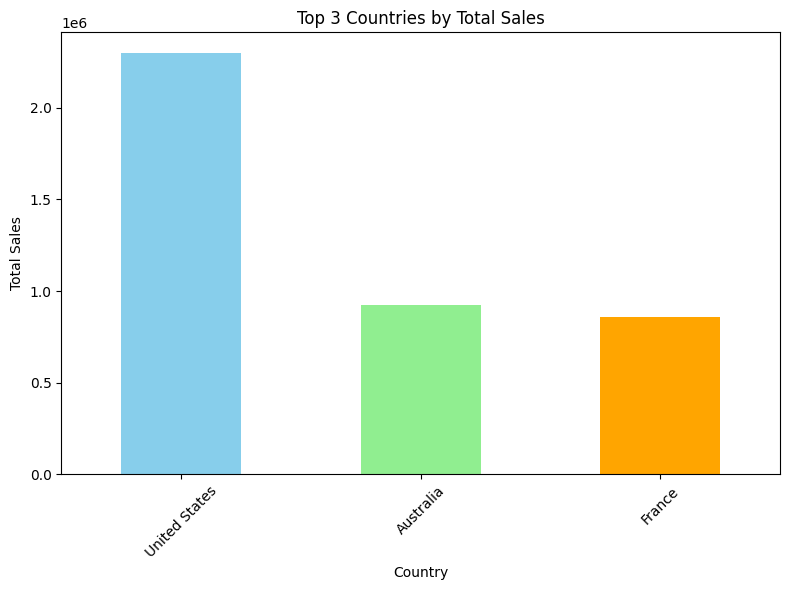

In [ ]:
# Load the dataframe using the correct path from the first successful execution
df = pd.read_excel('/content/drive/MyDrive/DA_Docs/DA-Docs/DA-session Docs/Data_walmart project-Docs/Walmart Global Superstore_Dataset.xlsx')

# Group by 'Country' and calculate the sum of 'Sales'
country_sales = df.groupby('Country')['Sales'].sum()

# Sort the results in descending order and select the top 3 countries
top_3_countries = country_sales.sort_values(ascending=False).head(3)

# Create a bar plot to visualize the total sales for these top 3 countries
plt.figure(figsize=(8, 6))
top_3_countries.plot(kind='bar', color=['skyblue', 'lightgreen', 'orange'])
plt.title('Top 3 Countries by Total Sales')
plt.ylabel('Total Sales')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.tight_layout()

# Display the plot
plt.show()